# Read the dataset

In [4]:
import pandas as pd
import numpy as np
import tensorflow as tf

df = pd.read_csv('data/jena_cleaned.csv', index_col='Date Time', parse_dates=True)

print(df.shape)
df.head()

I0000 00:00:1781300405.061516    9963 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781300405.733942    9963 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781300409.182095    9963 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


(420551, 14)


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
Date Time,,,,,,,,,,,,,,
2009-01-01 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
2009-01-01 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2009-01-01 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
2009-01-01 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
2009-01-01 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


# Select features and drop rows with NaN

In [5]:
features = ['T (degC)', 'p (mbar)', 'Tdew (degC)', 'rh (%)', 
            'VPact (mbar)', 'VPdef (mbar)', 'wv (m/s)', 'wd (deg)']

df = df[features]

df = df.dropna()

print(f"Shape after feature selection and NaN removal: {df.shape}")

Shape after feature selection and NaN removal: (420533, 8)


# Add cyclical encoding for wind direction and time

In [6]:
df['wd_sin'] = np.sin(2 * np.pi * df['wd (deg)'] / 360)
df['wd_cos'] = np.cos(2 * np.pi * df['wd (deg)'] / 360)
df = df.drop(columns=['wd (deg)'])

df['hour_sin'] = np.sin(2 * np.pi * df.index.hour / 24)
df['hour_cos'] = np.cos(2 * np.pi * df.index.hour / 24)
df['doy_sin'] = np.sin(2 * np.pi * df.index.dayofyear / 365)
df['doy_cos'] = np.cos(2 * np.pi * df.index.dayofyear / 365)

print(f"Shape after encoding: {df.shape}")
print(df.head())

Shape after encoding: (420533, 13)
                     T (degC)  p (mbar)  Tdew (degC)  rh (%)  VPact (mbar)  \
Date Time                                                                    
2009-01-01 00:10:00     -8.02    996.52        -8.90    93.3          3.11   
2009-01-01 00:20:00     -8.41    996.57        -9.28    93.4          3.02   
2009-01-01 00:30:00     -8.51    996.53        -9.31    93.9          3.01   
2009-01-01 00:40:00     -8.31    996.51        -9.07    94.2          3.07   
2009-01-01 00:50:00     -8.27    996.51        -9.04    94.1          3.08   

                     VPdef (mbar)  wv (m/s)    wd_sin    wd_cos  hour_sin  \
Date Time                                                                   
2009-01-01 00:10:00          0.22      1.03  0.464842 -0.885394       0.0   
2009-01-01 00:20:00          0.21      0.72  0.693402 -0.720551       0.0   
2009-01-01 00:30:00          0.20      0.19  0.146083 -0.989272       0.0   
2009-01-01 00:40:00          0.19

# Split the dataset into train/test/val chronologically

In [7]:
n = len(df)

train_size = int(n * 0.70) 
val_size   = int(n * 0.15) 
test_size  = n - train_size - val_size  

train_df = df[:train_size]
val_df   = df[train_size:train_size + val_size]
test_df  = df[train_size + val_size:]

print(f"Total rows: {n}")
print(f"Train size: {train_size} ({train_size/n*100:.1f}%)")
print(f"Val size:   {val_size} ({val_size/n*100:.1f}%)")
print(f"Test size:  {test_size} ({test_size/n*100:.1f}%)")
print()
print(f"Train: {train_df.index[0]} to {train_df.index[-1]}")
print(f"Val:   {val_df.index[0]} to {val_df.index[-1]}")
print(f"Test:  {test_df.index[0]} to {test_df.index[-1]}")

Total rows: 420533
Train size: 294373 (70.0%)
Val size:   63079 (15.0%)
Test size:  63081 (15.0%)

Train: 2009-01-01 00:10:00 to 2014-08-05 00:20:00
Val:   2014-08-05 00:30:00 to 2015-10-17 20:20:00
Test:  2015-10-17 20:30:00 to 2017-01-01 00:00:00


# Scale the dataset using MinMaxScaler

In [8]:
from sklearn.preprocessing import MinMaxScaler

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(train_df.drop(columns=['T (degC)']))
X_val_scaled   = scaler_X.transform(val_df.drop(columns=['T (degC)']))
X_test_scaled  = scaler_X.transform(test_df.drop(columns=['T (degC)']))

y_train_scaled = scaler_y.fit_transform(train_df[['T (degC)']])
y_val_scaled   = scaler_y.transform(val_df[['T (degC)']])
y_test_scaled  = scaler_y.transform(test_df[['T (degC)']])

# Helper functions and definitions

In [9]:
from keras.models import Sequential
from keras.layers import SimpleRNN, LSTM, Dense
from keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import pandas as pd

def create_sequences(X_data, y_data, window_size, forecast_horizon):
    X, y = [], []
    for i in range(len(X_data) - window_size - forecast_horizon):
        X.append(X_data[i:i+window_size])
        y.append(y_data[i+window_size+forecast_horizon])
    return np.array(X), np.array(y)

def rmsle(y_true, y_pred):
    return tf.sqrt(tf.reduce_mean(tf.square(tf.math.log1p(y_pred) - tf.math.log1p(y_true))))

# Experimental setup

In [10]:
FORECAST_HORIZON = 144  # 24 hours = 24 x 6 = 144 steps

WINDOW_SIZES = {
    '12h': 72,  # 12 hours = 12 x 6 = 72 steps
    '24h': 144, # 24 hours = 24 x 6 = 144 steps
    '48h': 288, # 48 hours = 48 x 6 = 288 steps
}

n_features = X_train_scaled.shape[1]
shift = abs(scaler_y.data_min_[0]) + 1.0

results = []
histories = {}

# Training SimpleRNN and LSTM for different window sizes

In [11]:
for window_label, window_size in WINDOW_SIZES.items():

    X_tr, y_tr = create_sequences(X_train_scaled, y_train_scaled, window_size, FORECAST_HORIZON)
    X_v,  y_v  = create_sequences(X_val_scaled,   y_val_scaled,   window_size, FORECAST_HORIZON)
    X_te, y_te = create_sequences(X_test_scaled,  y_test_scaled,  window_size, FORECAST_HORIZON)

    y_true_real = scaler_y.inverse_transform(y_te.reshape(-1, 1))

    for model_name, LayerType in [('SimpleRNN', SimpleRNN), ('LSTM', LSTM)]:

        print(f"\nTraining {model_name} | window={window_label} ({window_size} steps)")

        model = Sequential([
            LayerType(64, input_shape=(window_size, n_features)),
            Dense(1)
        ])
        model.compile(optimizer='adam', loss='mse', metrics=[rmsle])

        history = model.fit(
            X_tr, y_tr,
            epochs=30,
            batch_size=256,
            validation_data=(X_v, y_v),
            callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
            verbose=2
        )

        y_pred_scaled = model.predict(X_te, verbose=0)
        y_pred_real   = scaler_y.inverse_transform(y_pred_scaled)
        score = rmsle(y_true_real + shift, y_pred_real + shift).numpy()

        print(f"RMSLE: {score:.4f} | Epochs run: {len(history.history['loss'])}")

        model.save(f"model_{model_name}_{window_label}.keras")

        key = f"{model_name}_{window_label}"
        histories[key] = history.history
        results.append({
            'Model':        model_name,
            'Window':       window_label,
            'Window Steps': window_size,
            'RMSLE':        round(score, 4),
            'Epochs Run':   len(history.history['loss'])
        })


Training SimpleRNN | window=12h (72 steps)


E0000 00:00:1781300454.193580    9963 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/jagfoljersolen/APPROF/deep-learning-cnn-rnn-isep/venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30


W0000 00:00:1781300455.343833    9963 cpu_allocator_impl.cc:82] Allocation of 1016606592 exceeds 10% of free system memory.


1150/1150 - 35s - 31ms/step - loss: 0.0040 - rmsle: 0.0390 - val_loss: 0.0026 - val_rmsle: 0.0301
Epoch 2/30
1150/1150 - 32s - 28ms/step - loss: 0.0027 - rmsle: 0.0343 - val_loss: 0.0029 - val_rmsle: 0.0323
Epoch 3/30
1150/1150 - 34s - 30ms/step - loss: 0.0027 - rmsle: 0.0339 - val_loss: 0.0026 - val_rmsle: 0.0298
Epoch 4/30
1150/1150 - 33s - 29ms/step - loss: 0.0026 - rmsle: 0.0337 - val_loss: 0.0026 - val_rmsle: 0.0304
Epoch 5/30
1150/1150 - 32s - 28ms/step - loss: 0.0026 - rmsle: 0.0336 - val_loss: 0.0027 - val_rmsle: 0.0306
Epoch 6/30
1150/1150 - 31s - 27ms/step - loss: 0.0026 - rmsle: 0.0333 - val_loss: 0.0028 - val_rmsle: 0.0311
Epoch 7/30
1150/1150 - 33s - 28ms/step - loss: 0.0026 - rmsle: 0.0332 - val_loss: 0.0025 - val_rmsle: 0.0294
Epoch 8/30
1150/1150 - 32s - 28ms/step - loss: 0.0025 - rmsle: 0.0331 - val_loss: 0.0025 - val_rmsle: 0.0295
Epoch 9/30
1150/1150 - 32s - 28ms/step - loss: 0.0025 - rmsle: 0.0330 - val_loss: 0.0026 - val_rmsle: 0.0305
Epoch 10/30
1150/1150 - 32s - 

...

1149/1149 - 269s - 235ms/step - loss: 0.0036 - rmsle: 0.0362 - val_loss: 0.0025 - val_rmsle: 0.0294
Epoch 2/30
1149/1149 - 273s - 237ms/step - loss: 0.0025 - rmsle: 0.0331 - val_loss: 0.0025 - val_rmsle: 0.0295
Epoch 3/30
1149/1149 - 222s - 193ms/step - loss: 0.0025 - rmsle: 0.0328 - val_loss: 0.0025 - val_rmsle: 0.0292
Epoch 4/30
1149/1149 - 224s - 195ms/step - loss: 0.0025 - rmsle: 0.0326 - val_loss: 0.0026 - val_rmsle: 0.0297
Epoch 5/30
1149/1149 - 222s - 193ms/step - loss: 0.0024 - rmsle: 0.0321 - val_loss: 0.0026 - val_rmsle: 0.0298
Epoch 6/30
1149/1149 - 222s - 193ms/step - loss: 0.0023 - rmsle: 0.0317 - val_loss: 0.0026 - val_rmsle: 0.0298
Epoch 7/30
1149/1149 - 221s - 193ms/step - loss: 0.0023 - rmsle: 0.0312 - val_loss: 0.0026 - val_rmsle: 0.0296
Epoch 8/30
1149/1149 - 222s - 193ms/step - loss: 0.0022 - rmsle: 0.0307 - val_loss: 0.0026 - val_rmsle: 0.0296
RMSLE: 0.0902 | Epochs run: 8

Training SimpleRNN | window=48h (288 steps)


/home/jagfoljersolen/APPROF/deep-learning-cnn-rnn-isep/venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
W0000 00:00:1781305294.304306    9963 cpu_allocator_impl.cc:82] Allocation of 4063440384 exceeds 10% of free system memory.


Epoch 1/30
1149/1149 - 118s - 103ms/step - loss: 0.0046 - rmsle: nan - val_loss: 0.0028 - val_rmsle: 0.0308
Epoch 2/30
1149/1149 - 102s - 89ms/step - loss: 0.0027 - rmsle: 0.0342 - val_loss: 0.0027 - val_rmsle: 0.0304
Epoch 3/30
1149/1149 - 103s - 90ms/step - loss: 0.0027 - rmsle: 0.0340 - val_loss: 0.0026 - val_rmsle: 0.0300
Epoch 4/30
1149/1149 - 102s - 89ms/step - loss: 0.0026 - rmsle: 0.0338 - val_loss: 0.0029 - val_rmsle: 0.0314
Epoch 5/30
1149/1149 - 223s - 194ms/step - loss: 0.0026 - rmsle: 0.0337 - val_loss: 0.0029 - val_rmsle: 0.0312
Epoch 6/30
1149/1149 - 212s - 184ms/step - loss: 0.0026 - rmsle: 0.0335 - val_loss: 0.0027 - val_rmsle: 0.0303
Epoch 7/30
1149/1149 - 82s - 71ms/step - loss: 0.0026 - rmsle: 0.0334 - val_loss: 0.0028 - val_rmsle: 0.0313
Epoch 8/30
1149/1149 - 82s - 71ms/step - loss: 0.0026 - rmsle: 0.0333 - val_loss: 0.0030 - val_rmsle: 0.0325
RMSLE: 0.0932 | Epochs run: 8

Training LSTM | window=48h (288 steps)


/home/jagfoljersolen/APPROF/deep-learning-cnn-rnn-isep/venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
1149/1149 - 416s - 362ms/step - loss: 0.0034 - rmsle: 0.0360 - val_loss: 0.0029 - val_rmsle: 0.0318
Epoch 2/30
1149/1149 - 403s - 351ms/step - loss: 0.0025 - rmsle: 0.0331 - val_loss: 0.0025 - val_rmsle: 0.0295
Epoch 3/30
1149/1149 - 406s - 353ms/step - loss: 0.0025 - rmsle: 0.0328 - val_loss: 0.0025 - val_rmsle: 0.0291
Epoch 4/30
1149/1149 - 434s - 378ms/step - loss: 0.0024 - rmsle: 0.0325 - val_loss: 0.0026 - val_rmsle: 0.0298
Epoch 5/30
1149/1149 - 405s - 352ms/step - loss: 0.0024 - rmsle: 0.0324 - val_loss: 0.0025 - val_rmsle: 0.0294
Epoch 6/30
1149/1149 - 393s - 342ms/step - loss: 0.0024 - rmsle: 0.0321 - val_loss: 0.0026 - val_rmsle: 0.0298
Epoch 7/30
1149/1149 - 404s - 351ms/step - loss: 0.0023 - rmsle: 0.0317 - val_loss: 0.0026 - val_rmsle: 0.0297
Epoch 8/30
1149/1149 - 381s - 332ms/step - loss: 0.0023 - rmsle: 0.0315 - val_loss: 0.0026 - val_rmsle: 0.0297
RMSLE: 0.0904 | Epochs run: 8


# Results table

In [12]:
results_df = pd.DataFrame(results)
print("=== Experiment Results ===")
print(results_df.to_string(index=False))

=== Experiment Results ===
    Model Window  Window Steps  RMSLE  Epochs Run
SimpleRNN    12h            72 0.0907          19
     LSTM    12h            72 0.0909          11
SimpleRNN    24h           144 0.0913          12
     LSTM    24h           144 0.0902           8
SimpleRNN    48h           288 0.0932           8
     LSTM    48h           288 0.0904           8


# Create the plots to visualize the loss curves

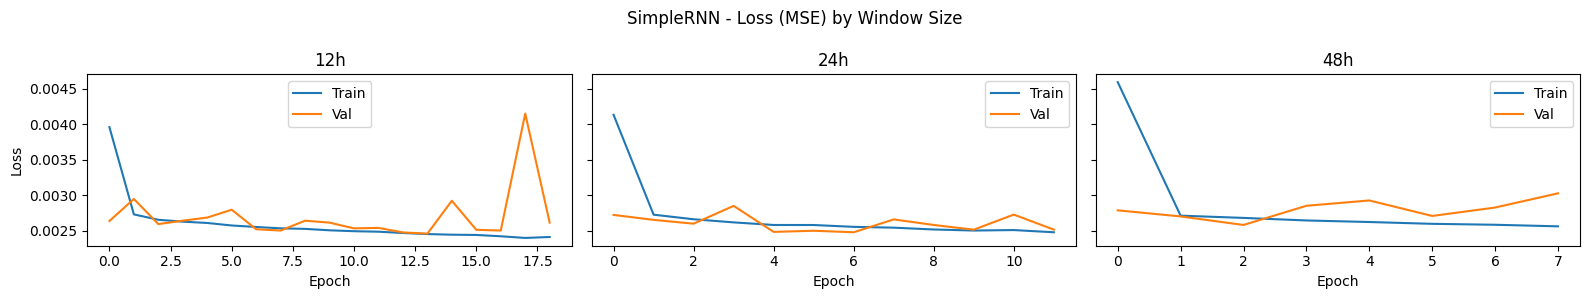

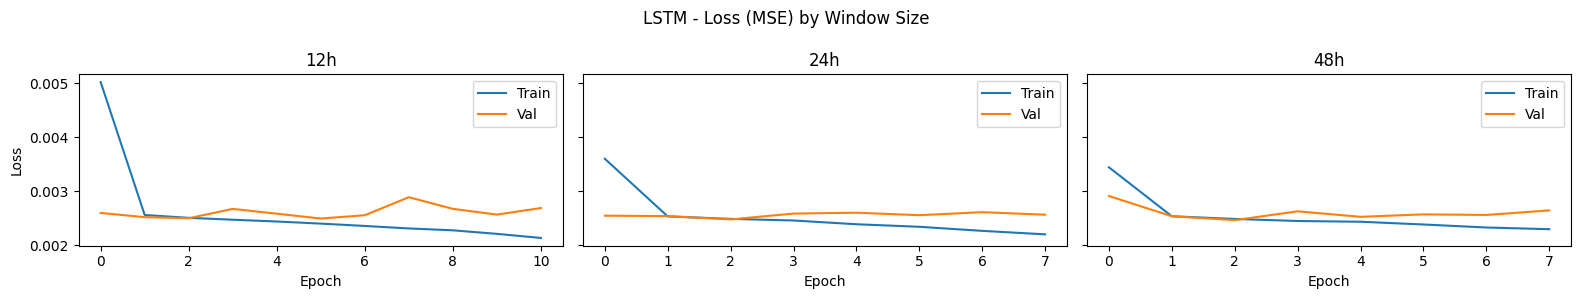

In [13]:
for model_name in ['SimpleRNN', 'LSTM']:
    fig, axes = plt.subplots(1, len(WINDOW_SIZES), figsize=(16, 3), sharey=True)
    fig.suptitle(f'{model_name} - Loss (MSE) by Window Size')

    for ax, (window_label, _) in zip(axes, WINDOW_SIZES.items()):
        key = f"{model_name}_{window_label}"
        h = histories[key]
        ax.plot(h['loss'], label='Train')
        ax.plot(h['val_loss'], label='Val')
        ax.set_title(window_label)
        ax.set_xlabel('Epoch')
        ax.legend()

    axes[0].set_ylabel('Loss')
    plt.tight_layout()
    plt.show()